<a href="https://colab.research.google.com/github/3madTaha/Cloud-Computing/blob/main/Tutorials/Tutorial4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install -q datasets

In [12]:
from datasets import load_dataset

dataset = load_dataset("BrandonFors/Plant-Diseases-PlantVillage-Dataset")
dataset

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/321M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/362M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/170M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43456 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10849 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 43456
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10849
    })
})

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x7D9CE0557A70>, 'label': 0}


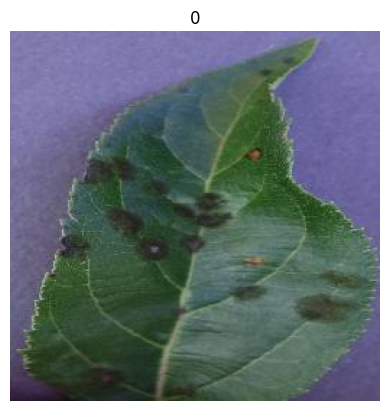

In [13]:
import matplotlib.pyplot as plt

sample = dataset["train"][0]

print(sample)
plt.imshow(sample["image"])
plt.title(sample["label"])
plt.axis("off")
plt.show()

In [32]:
# Install necessary libraries for Transformers and PyTorch
!pip install -q transformers torch

In [33]:
from transformers import AutoImageProcessor, AutoModelForImageClassification

# Load the processor for ViT
image_processor = AutoImageProcessor.from_pretrained(model_name)

# Load the pre-trained ViT model and adapt it to our number of classes
# model_name and num_labels are available from the previous kernel state.
model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    ignore_mismatched_sizes=True # Allows changing the size of the output layer
)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [34]:
def preprocess_images(examples):
    # The image processor automatically handles resizing, normalization, and conversion to PyTorch tensors
    # It expects a list of PIL Image objects or numpy arrays
    images = [image.convert("RGB") for image in examples["image"]]
    processed_inputs = image_processor(images, return_tensors="pt")

    # Add the labels to the processed inputs
    processed_inputs["labels"] = examples["label"]
    return processed_inputs

# Apply the preprocessing function to all splits of the dataset
# Using 'with_transform' is efficient as it applies transformations on the fly
# without modifying the underlying dataset directly until samples are accessed.
processed_dataset = dataset.with_transform(preprocess_images)

# Let's inspect a single sample after preprocessing to see the new format
# Note: When accessing samples from 'processed_dataset', the 'preprocess_images' function is called.
sample_processed = processed_dataset["train"][0]

print("Keys in processed sample:", sample_processed.keys())
print("Shape of pixel values:", sample_processed["pixel_values"].shape)
print("Label:", sample_processed["labels"])


Keys in processed sample: dict_keys(['pixel_values', 'labels'])
Shape of pixel values: torch.Size([3, 224, 224])
Label: 0


In [35]:
# Training parameters
learning_rate = 2e-5
batch_size = 32
num_epochs = 5
weight_decay = 0.01


In [38]:
from transformers import TrainingArguments, Trainer
import evaluate # Changed from: from datasets import load_metric
import numpy as np
from transformers import DefaultDataCollator

# Define the data collator
data_collator = DefaultDataCollator(return_tensors="pt")

# Define evaluation metric
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)


In [1]:
!pip install -q transformers datasets evaluate accelerate torch torchvision

from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification
from transformers import TrainingArguments, Trainer, DefaultDataCollator
import evaluate
import numpy as np

# 1. Dataset
dataset = load_dataset("BrandonFors/Plant-Diseases-PlantVillage-Dataset")

labels = dataset["train"].features["label"].names
num_labels = len(labels)

small_train = dataset["train"].shuffle(seed=42).select(range(3000))
small_test = dataset["test"].shuffle(seed=42).select(range(1000))

# 2. Model + Processor
model_name = "google/vit-base-patch16-224-in21k"

image_processor = AutoImageProcessor.from_pretrained(model_name)

model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label={i: label for i, label in enumerate(labels)},
    label2id={label: i for i, label in enumerate(labels)}
)

# 3. Preprocess
def preprocess_images(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    inputs = image_processor(images, return_tensors="pt")
    inputs["labels"] = examples["label"]
    return inputs

train_ds = small_train.with_transform(preprocess_images)
test_ds = small_test.with_transform(preprocess_images)

# 4. Metric
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=preds, references=labels)

# 5. Training arguments
training_args = TrainingArguments(
    output_dir="./plant_vit_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    remove_unused_columns=False
)

# 6. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=DefaultDataCollator(return_tensors="pt"),
    compute_metrics=compute_metrics
)

trainer.train()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/321M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/362M [00:00<?, ?B/s]

...

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,2.147356,2.115522,0.808000
2,1.762562,1.809567,0.856000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=750, training_loss=2.2310912170410155, metrics={'train_runtime': 305.6418, 'train_samples_per_second': 19.631, 'train_steps_per_second': 2.454, 'total_flos': 4.65101957505024e+17, 'train_loss': 2.2310912170410155, 'epoch': 2.0})

In [2]:
trainer.save_model("./best_plant_disease_model")
image_processor.save_pretrained("./best_plant_disease_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['./best_plant_disease_model/preprocessor_config.json']